In [2]:
#Import and load the clean data
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/Owner/world-cup-predictor/data/processed/matches_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
df.head()

(49287, 8)


,date,home_team,away_team,home_score,away_score,tournament,neutral,outcome
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,D
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,H
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,H
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,False,D
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,False,H


In [3]:
tournament_weights = {
    'FIFA World Cup':                  8,
    'UEFA Euro':                       7,
    'Copa América':                    7,
    'Africa Cup of Nations':           7,
    'AFC Asian Cup':                   7,
    'CONCACAF Gold Cup':               6,
    'UEFA Nations League':             5,
    'FIFA World Cup qualification':    5,
    'UEFA Euro qualification':         4,
    'Copa América qualification':      4,
    'Friendly':                        1,
}

df['tournament_weight'] = (df['tournament']
    .map(tournament_weights)
    .fillna(3))  # unknown tournaments get a middle weight

print("Weight distribution:")
print(df['tournament_weight'].value_counts().sort_index())

Weight distribution:
tournament_weight
1.0    18252
3.0    16060
4.0     2832
5.0     9429
7.0     1678
8.0     1036
Name: count, dtype: int64


In [11]:
# We need to reshape: each match appears twice
# once from home team's perspective, once from away team's

def build_team_records(df):
    records = []
    
    for _, row in df.iterrows():
        # Home team perspective
        records.append({
            'date':       row['date'],
            'team':       row['home_team'],
            'opponent':   row['away_team'],
            'goals_for':  row['home_score'],
            'goals_against': row['away_score'],
            'was_home':   True,
            'result':     1 if row['outcome'] == 'H' else (0.5 if row['outcome'] == 'D' else 0),
            'tournament_weight': row['tournament_weight']
        })
        # Away team perspective
        records.append({
            'date':       row['date'],
            'team':       row['away_team'],
            'opponent':   row['home_team'],
            'goals_for':  row['away_score'],
            'goals_against': row['home_score'],
            'was_home':   False,
            'result':     1 if row['outcome'] == 'A' else (0.5 if row['outcome'] == 'D' else 0),
            'tournament_weight': row['tournament_weight']
        })
    
    return pd.DataFrame(records).sort_values('date').reset_index(drop=True)

team_records = build_team_records(df)
print(team_records.shape)
team_records.head(10)

(98574, 8)


,date,team,opponent,goals_for,goals_against,was_home,result,tournament_weight
0,1872-11-30,Scotland,England,0.0,0.0,True,0.5,1.0
1,1872-11-30,England,Scotland,0.0,0.0,False,0.5,1.0
2,1873-03-08,England,Scotland,4.0,2.0,True,1.0,1.0
3,1873-03-08,Scotland,England,2.0,4.0,False,0.0,1.0
4,1874-03-07,Scotland,England,2.0,1.0,True,1.0,1.0
5,1874-03-07,England,Scotland,1.0,2.0,False,0.0,1.0
6,1875-03-06,England,Scotland,2.0,2.0,True,0.5,1.0
7,1875-03-06,Scotland,England,2.0,2.0,False,0.5,1.0
8,1876-03-04,Scotland,England,3.0,0.0,True,1.0,1.0
9,1876-03-04,England,Scotland,0.0,3.0,False,0.0,1.0


In [12]:
def rolling_form(team_records, window=10):
    """
    For each team, at each point in time, calculate:
    - Rolling win rate (last N matches)
    - Rolling avg goals scored
    - Rolling avg goals conceded
    All calculated using only PAST matches (no data leakage)
    """
    team_records = team_records.sort_values(['team', 'date'])
    
    grp = team_records.groupby('team')
    
    # shift(1) is critical — it ensures we only use past results
    # without shift, we'd be including the current match in its own features (leakage)
    team_records['form_win_rate']      = grp['result'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=3).mean())
    
    team_records['form_goals_scored']  = grp['goals_for'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=3).mean())
    
    team_records['form_goals_conceded']= grp['goals_against'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=3).mean())
    
    return team_records

team_records = rolling_form(team_records, window=10)

print("Sample — England's recent record:")
print(team_records[team_records['team'] == 'England']
      [['date','opponent','result','form_win_rate','form_goals_scored']]
      .tail(10))

Sample — England's recent record:
            date opponent  result  form_win_rate  form_goals_scored
97219 2025-09-09   Serbia     1.0           0.80           2.300000
97346 2025-10-09    Wales     1.0           0.80           2.600000
97547 2025-10-14   Latvia     1.0           0.90           2.800000
97655 2025-11-13   Serbia     1.0           0.90           3.000000
97799 2025-11-16  Albania     1.0           0.90           2.900000
98243 2026-03-27  Uruguay     0.5           0.90           2.600000
98390 2026-03-31    Japan     0.0           0.85           2.500000
98477 2026-06-17  Croatia     0.5           0.75           2.200000
98521 2026-06-23    Ghana     0.5           0.70           2.333333
98567 2026-06-27   Panama     0.5           0.75           2.500000


In [17]:
def head_to_head(df, window=10):
    """
    For each match, look back at the last N meetings 
    between these two specific teams.
    """
    h2h_records = []
    
    df_sorted = df.sort_values('date').reset_index(drop=True)
    
    for idx, row in df_sorted.iterrows():
        home, away = row['home_team'], row['away_team']
        match_date = row['date']
        
        # All prior meetings between these two teams (either way around)
        past = df_sorted[
            (df_sorted['date'] < match_date) &
            (((df_sorted['home_team'] == home) & (df_sorted['away_team'] == away)) |
             ((df_sorted['home_team'] == away) & (df_sorted['away_team'] == home)))
        ].tail(window)
        
        if len(past) == 0:
            h2h_records.append({'h2h_home_wins': np.nan, 
                                 'h2h_draws': np.nan, 
                                 'h2h_away_wins': np.nan})
            continue
        
        # Count outcomes from home team's perspective
        home_wins = ((past['home_team'] == home) & (past['outcome'] == 'H')).sum() + \
                    ((past['away_team'] == home) & (past['outcome'] == 'A')).sum()
        away_wins = ((past['home_team'] == away) & (past['outcome'] == 'H')).sum() + \
                    ((past['away_team'] == away) & (past['outcome'] == 'A')).sum()
        draws     = (past['outcome'] == 'D').sum()
        total     = len(past)
        
        h2h_records.append({
            'h2h_home_wins': home_wins / total,
            'h2h_draws':     draws / total,
            'h2h_away_wins': away_wins / total,
        })
    
    return pd.DataFrame(h2h_records)

print("Calculating head-to-head records (this takes ~1 min)...")
h2h_df = head_to_head(df)
df = pd.concat([df.reset_index(drop=True), h2h_df], axis=1)
print("Done.")
df[['home_team','away_team','h2h_home_wins','h2h_draws','h2h_away_wins']].head(10)

Calculating head-to-head records (this takes ~1 min)...
Done.


,home_team,away_team,h2h_home_wins,h2h_home_wins,h2h_draws,h2h_draws,h2h_away_wins,h2h_away_wins
0,Scotland,England,NaN,NaN,NaN,NaN,NaN,NaN
1,England,Scotland,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
2,Scotland,England,0.000000,0.000000,0.500000,0.500000,0.500000,0.500000
3,England,Scotland,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
4,Scotland,England,0.250000,0.250000,0.500000,0.500000,0.250000,0.250000
5,Scotland,Wales,NaN,NaN,NaN,NaN,NaN,NaN
6,England,Scotland,0.200000,0.200000,0.400000,0.400000,0.400000,0.400000
7,Wales,Scotland,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
8,Scotland,England,0.500000,0.500000,0.333333,0.333333,0.166667,0.166667
9,Scotland,Wales,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000


In [19]:
# Separate home and away form stats
home_form = (team_records[team_records['was_home'] == True]
             [['date','team','form_win_rate','form_goals_scored','form_goals_conceded']]
             .rename(columns={
                 'team': 'home_team',
                 'form_win_rate':      'home_form_win_rate',
                 'form_goals_scored':  'home_form_goals_scored',
                 'form_goals_conceded':'home_form_goals_conceded',
             }))

away_form = (team_records[team_records['was_home'] == False]
             [['date','team','form_win_rate','form_goals_scored','form_goals_conceded']]
             .rename(columns={
                 'team': 'away_team',
                 'form_win_rate':         'away_form_win_rate',
                 'form_goals_scored':     'away_form_goals_scored',
                 'form_goals_conceded':   'away_form_goals_conceded',
             }))

# Join onto the main dataframe
df = df.merge(home_form, on=['date','home_team'], how='left')
df = df.merge(away_form, on=['date','away_team'], how='left')

print("Columns now:", df.columns.tolist())
print("\nNull counts in new features:")
print(df[['home_form_win_rate','away_form_win_rate',
          'h2h_home_wins']].isnull().sum())

Columns now: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'outcome', 'tournament_weight', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'home_form_win_rate_x', 'home_form_goals_scored_x', 'home_form_goals_conceded_x', 'away_form_win_rate_x', 'away_form_goals_scored_x', 'away_form_goals_conceded_x', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'home_form_win_rate_y', 'home_form_goals_scored_y', 'home_form_goals_conceded_y', 'away_form_win_rate_y', 'away_form_goals_scored_y', 'away_form_goals_conceded_y', 'home_form_win_rate', 'home_form_goals_scored', 'home_form_goals_conceded', 'away_form_win_rate', 'away_form_goals_scored', 'away_form_goals_conceded']

Null counts in new features:
home_form_win_rate     432
away_form_win_rate     602
h2h_home_wins         7697
h2h_home_wins         7748
dtype: int64


In [21]:
# Teams with no history yet get league average (0.4 win rate)
form_cols = ['home_form_win_rate','home_form_goals_scored','home_form_goals_conceded',
             'away_form_win_rate','away_form_goals_scored','away_form_goals_conceded']
df[form_cols] = df[form_cols].fillna(df[form_cols].mean())

# H2H nulls -> equal probability (no prior meetings)
df['h2h_home_wins'] = df['h2h_home_wins'].fillna(0.33)
df['h2h_draws'] = df['h2h_draws'].fillna(0.33)
df['h2h_away_wins'] = df['h2h_away_wins'].fillna(0.34)

# Home advantage flag (already in data as 'neutral')
df['is_neutral'] = df['neutral'].astype(int)

# Form differential - simple but powerful still
df['form_diff'] = df['home_form_win_rate'] - df['away_form_win_rate']
df['goals_diff'] = df['home_form_goals_scored'] - df['away_form_goals_scored']

print("Final shape:", df.shape)
df.head(3)

Final shape: (50576, 36)


,date,home_team,away_team,home_score,away_score,tournament,neutral,outcome,tournament_weight,h2h_home_wins,...,away_form_goals_conceded_y,home_form_win_rate,home_form_goals_scored,home_form_goals_conceded,away_form_win_rate,away_form_goals_scored,away_form_goals_conceded,is_neutral,form_diff,goals_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,D,1.0,0.33,...,NaN,0.504506,1.499268,1.462098,0.494372,1.466554,1.506269,0,0.010134,0.032714
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,H,1.0,0.00,...,NaN,0.504506,1.499268,1.462098,0.494372,1.466554,1.506269,0,0.010134,0.032714
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,H,1.0,0.00,...,NaN,0.504506,1.499268,1.462098,0.494372,1.466554,1.506269,0,0.010134,0.032714


In [22]:
FEATURES = [
    'home_form_win_rate',
    'home_form_goals_scored',
    'home_form_goals_conceded',
    'away_form_win_rate',
    'away_form_goals_scored',
    'away_form_goals_conceded',
    'h2h_home_wins',
    'h2h_draws',
    'h2h_away_wins',
    'tournament_weight',
    'is_neutral',
    'form_diff',
    'goals_diff',
]

TARGET = 'outcome'

# Drop rows where we don't have enough history (early matches)
df_model = df[FEATURES + [TARGET, 'date', 'home_team', 'away_team']].dropna()

print(f"Rows available for modelling: {len(df_model)} / {len(df)} total")
print(f"\nTarget distribution:\n{df_model[TARGET].value_counts()}")

df_model.to_csv('../data/processed/features.csv', index=False)
print("\nSaved to data/processed/features.csv")

Rows available for modelling: 50576 / 50576 total

Target distribution:
outcome
H    24935
A    14185
D    11456
Name: count, dtype: int64

Saved to data/processed/features.csv


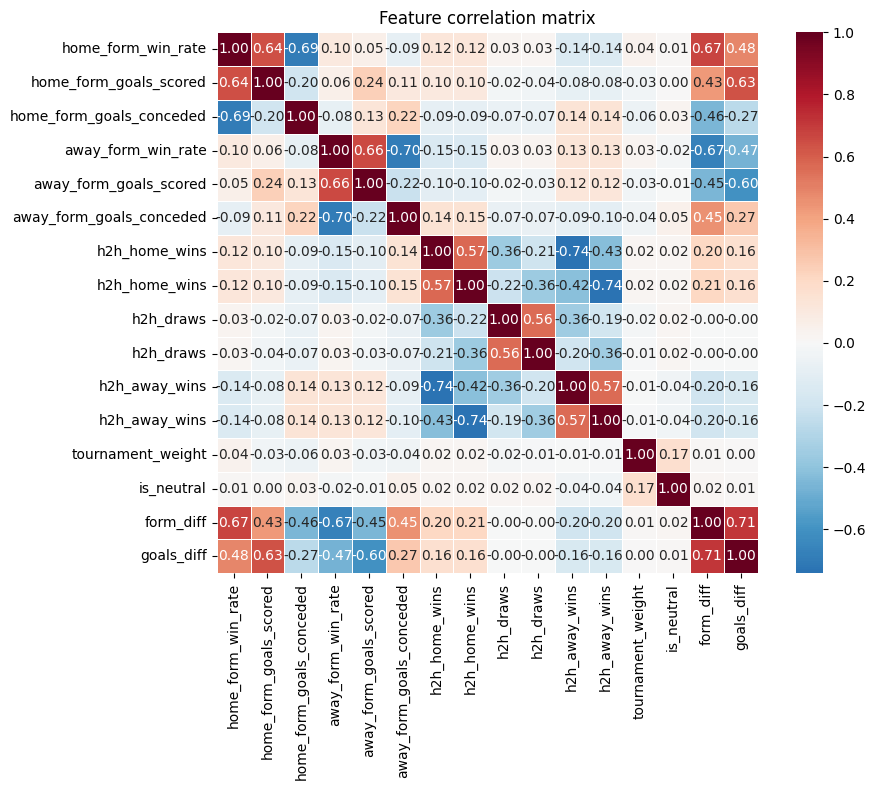

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_model[FEATURES].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=150)
plt.show()